# 2D POD heatmap analysis — paper revision

Updated to use the **100 m wind** datasets for both US and Global. The
new global stage-2 CSV (`Run_100m_20260428`) only carries
`location, plume_label` and 12 other minimal columns — it does not
re-merge per-scene scalar features. So we **merge in** the
per-scene scalars (`surface_albedo`, `wind_speed`, …) from `Run_3` on
the (`location`, `utc_time`) join key, giving us:
**new 100 m plume labels + Run_3 scalar features**.

| side | label source | feature source |
|---|---|---|
| **US** | `pipeline_100m_run/Run_100m_20260414/` (100 m, LST-fixed) | same file (B5 augment writes scalars in place) |
| **Global** | `pipeline_test_labelling_100m/Run_100m_20260428/` (100 m) | merged from `data/world/Run_3/...with_fuel.csv` on (location, utc_time) |

Albedo column preference: `surface_albedo` (continuous, 440 nm climatology)
over `surface_albedo_nitrogendioxide_window` (quantized lookup at NO₂
retrieval wavelength) to avoid overlapping percentile bins.

**Outputs** (in `results/paper_figures/`):
- `pod_2d_heatmap_emission.{pdf,png}` — 2×2: (US/Global) × (Albedo/Wind), emission on x-axis
- `pod_2d_heatmap_wind_albedo.{pdf,png}` — 1×2: (US, Global) Wind Speed × Surface Albedo

In [1]:
from pathlib import Path
from typing import Dict, Optional
from math import radians, log10, sin, cos, asin, sqrt

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
from sklearn.neighbors import BallTree
from tqdm.auto import tqdm

# ── Paths (paper revision: 100 m wind for both US and World) ──────────
US_HOURLY_CSV    = Path('/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/'
                         'Run_100m_20260414/'
                         'updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv')
US_FACILITY_CSV  = Path('/net/fs06/d3/rzhuang/TROPOMI/data/us/'
                         'facility_emissions_by_plant_comprehensive.csv')
US_ANNUAL_CSV    = Path('/net/fs06/d3/rzhuang/TROPOMI/data/us/'
                         'annual-emissions-facility-aggregation-2019-2024.csv')
# World: 2026-04-28 100 m re-labelling stage-2 output (ERA5 100 m wind, replaces
# the 10 m TROPOMI-embedded wind used by Run_3). Only `location` + `plume_label`
# come from this file; per-scene scalar features (surface_albedo, wind_speed,
# etc.) are merged in from Run_3 below — Run_3 used the same plant × overpass
# universe so (location, utc_time) is a 1:1 join key.
WORLD_EMIT_CSV   = Path('/net/fs06/d3/rzhuang/TROPOMI/data/world/'
                         'pipeline_test_labelling_100m/Run_100m_20260428/'
                         'valid_tropomi_emissions_with_qa.csv')
WORLD_FEATURES_CSV = Path('/net/fs06/d3/rzhuang/TROPOMI/data/world/Run_3/'
                          'updated_tropomi_emissions_full_variables_with_fuel.csv')
WORLD_LOC_CSV    = Path('/net/fs06/d3/rzhuang/TROPOMI/data/world/'
                         'power_plant_location/power_plants_with_combined_nearby_stats.csv')
WORLD_CITIES_CSV = Path('/net/fs06/d3/rzhuang/TROPOMI/data/world/worldcities.csv')

OUT_DIR = Path('/net/fs06/d3/rzhuang/TROPOMI/results/paper_figures')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────
EARTH_RADIUS_KM      = 6371.0
PLANT_RADIUS_BASE_KM = 20.0
CITY_POP_THRESHOLD   = 200_000
CITY_RADIUS_BASE_KM  = 10.0
CITY_RADIUS_SCALE    = 9.0
CITY_RADIUS_MAX_KM   = 90.0
N_BINS_X             = 10
N_BINS_Y             = 10
MIN_COUNT            = 5
LBS_TO_KG            = 0.45359237
TARGET_CANDIDATES = ['plume_label', 'label', 'detected', 'is_detected', 'target', 'y']

# ── Style: Nimbus Roman ──────────────────────────────────────────────
nimbus_path = None
for path in fm.findSystemFonts():
    pl = path.lower()
    if (('nimbusroman' in pl or 'nimbus_roman' in pl)
            and 'bold' not in pl and 'italic' not in pl and 'oblique' not in pl):
        nimbus_path = path; break
if nimbus_path:
    fm.fontManager.addfont(nimbus_path)
plt.rcdefaults()
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'Nimbus Roman' if nimbus_path else 'serif',
    'font.size': 11, 'axes.linewidth': 0.8,
    'figure.facecolor': 'white',
})

/home/rzhuang/.conda/envs/rzhuang-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Geometry / year helpers ──────────────────────────────────────────
def haversine(p1, p2, radius_km=EARTH_RADIUS_KM):
    lat1, lon1 = p1; lat2, lon2 = p2
    dlat = radians(lat2 - lat1); dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    return 2 * radius_km * asin(sqrt(a))

def extract_year(df):
    if 'year' in df.columns:
        return df
    if 'utc_time' not in df.columns:
        df['year'] = 2024; return df
    s = df['utc_time']
    try:
        year = pd.to_datetime(s, utc=True, errors='coerce', format='mixed').dt.year
    except TypeError:
        year = pd.to_datetime(s, utc=True, errors='coerce').dt.year
    if year.isna().any():
        guess = pd.to_numeric(s.astype(str).str[:4], errors='coerce')
        year = year.fillna(guess)
    df['year'] = year.astype('Int64')
    return df

def _to_str_set(x):
    return set(pd.Series(list(x)).dropna().astype(str).str.strip())

In [3]:
# ── Interference filter (US per-year, Global one-shot) ───────────────
def us_interference_by_year(plants_df, annual_emissions_df, cities_df,
                            plant_subset_ids=None) -> Dict[int, set]:
    if plant_subset_ids is not None:
        plants_df = plants_df[plants_df['Facility_ID'].isin(plant_subset_ids)].copy()
        annual_emissions_df = annual_emissions_df[
            annual_emissions_df['Facility ID'].isin(plant_subset_ids)].copy()
    p = plants_df.copy()
    if 'Facility_ID' in p.columns:
        p = p.rename(columns={'Facility_ID': 'Facility ID'})
    p = p.drop(columns=['Latitude', 'Longitude', 'State', 'Facility_Name', 'Primary_Fuel_Type'],
               errors='ignore')
    full = pd.merge(annual_emissions_df, p, on='Facility ID', how='left')
    full.dropna(subset=['Latitude', 'Longitude'], inplace=True)
    cf = cities_df[cities_df['population'] >= CITY_POP_THRESHOLD].copy()
    cf['lat_rad'] = np.radians(cf['latitude']); cf['lon_rad'] = np.radians(cf['longitude'])
    city_tree = BallTree(cf[['lat_rad', 'lon_rad']].values, metric='haversine') if len(cf) else None
    out = {}
    for year in sorted(full['Year'].unique()):
        py = full[full['Year'] == year].copy()
        if py.empty:
            out[year] = set(); continue
        py['lat_rad'] = np.radians(py['Latitude']); py['lon_rad'] = np.radians(py['Longitude'])
        ptree = BallTree(py[['lat_rad', 'lon_rad']].values, metric='haversine')
        bad = set()
        for _, t in py.iterrows():
            tid, tlat, tlon = t['Facility ID'], t['Latitude'], t['Longitude']
            te = t.get('NOx Mass (short tons)', 0)
            if pd.isna(tlat) or pd.isna(tlon): continue
            tc = np.array([[radians(tlat), radians(tlon)]])
            for j in ptree.query_radius(tc, r=PLANT_RADIUS_BASE_KM/EARTH_RADIUS_KM)[0]:
                src = py.iloc[j]
                if src['Facility ID'] == tid: continue
                se = src.get('NOx Mass (short tons)', 0)
                if pd.notna(se) and se > te:
                    if haversine((tlat, tlon), (src['Latitude'], src['Longitude'])) < PLANT_RADIUS_BASE_KM:
                        bad.add(str(tid).strip()); break
            if city_tree and tid not in bad:
                for j in city_tree.query_radius(tc, r=CITY_RADIUS_MAX_KM/EARTH_RADIUS_KM)[0]:
                    c = cf.iloc[j]
                    r = min(CITY_RADIUS_BASE_KM + log10(max(1, c['population'])) * CITY_RADIUS_SCALE,
                            CITY_RADIUS_MAX_KM)
                    if haversine((tlat, tlon), (c['latitude'], c['longitude'])) < r:
                        bad.add(str(tid).strip()); break
        out[year] = bad
    return out

def filter_us_by_year(df, year_bad):
    out = []
    for year in sorted(df['year'].unique()):
        d = df[df['year'] == year].copy()
        if year in year_bad:
            ids = {str(x).strip() for x in year_bad[year]}
            d = d[~d['location'].astype(str).str.strip().isin(ids)]
        out.append(d)
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

def global_interference(plants_df, cities_df, plant_subset_ids=None):
    if plant_subset_ids is not None:
        plants_df = plants_df[plants_df['ID'].isin(plant_subset_ids)].copy()
    p = plants_df.copy()
    p['annual_nox_emission'] = p['nox_emis_ty'] if 'nox_emis_ty' in p.columns else -p.index
    p['lat_rad'] = np.radians(p['latitude']); p['lon_rad'] = np.radians(p['longitude'])
    ptree = BallTree(p[['lat_rad', 'lon_rad']].values, metric='haversine')
    cf = cities_df[cities_df['population'] >= CITY_POP_THRESHOLD].copy()
    cf['lat_rad'] = np.radians(cf['latitude']); cf['lon_rad'] = np.radians(cf['longitude'])
    city_tree = BallTree(cf[['lat_rad', 'lon_rad']].values, metric='haversine') if len(cf) else None
    bad = set()
    for idx, t in tqdm(p.iterrows(), total=len(p), desc='Global interference'):
        tid, tlat, tlon = t['ID'], t['latitude'], t['longitude']
        te = t.get('annual_nox_emission', 0)
        if pd.isna(tlat) or pd.isna(tlon): continue
        tc = np.array([[radians(tlat), radians(tlon)]])
        for j in ptree.query_radius(tc, r=PLANT_RADIUS_BASE_KM/EARTH_RADIUS_KM)[0]:
            if j == idx: continue
            src = p.iloc[j]; se = src.get('annual_nox_emission', 0)
            if pd.notna(se) and se > te:
                if haversine((tlat, tlon), (src['latitude'], src['longitude'])) < PLANT_RADIUS_BASE_KM:
                    bad.add(str(tid).strip()); break
        if city_tree and tid not in bad:
            for j in city_tree.query_radius(tc, r=CITY_RADIUS_MAX_KM/EARTH_RADIUS_KM)[0]:
                c = cf.iloc[j]
                r = min(CITY_RADIUS_BASE_KM + log10(max(1, c['population'])) * CITY_RADIUS_SCALE,
                        CITY_RADIUS_MAX_KM)
                if haversine((tlat, tlon), (c['latitude'], c['longitude'])) < r:
                    bad.add(str(tid).strip()); break
    return bad

def filter_global(df, bad):
    return df[~df['location'].astype(str).str.strip().isin(_to_str_set(bad))].copy()

In [4]:
# ── 2D POD heatmap helpers ───────────────────────────────────────────
def find_target_col(df):
    for c in TARGET_CANDIDATES:
        if c in df.columns: return c
    raise KeyError(TARGET_CANDIDATES)

def resolve_feature_col(df, candidates):
    for c in candidates:
        if c in df.columns: return c
    raise KeyError(candidates)

def compute_2d_pod_heatmap(df, x_col, y_col, target_col,
                            n_bins_x=N_BINS_X, n_bins_y=N_BINS_Y,
                            min_count=MIN_COUNT, log_x=False, log_y=False):
    x = pd.to_numeric(df[x_col], errors='coerce')
    y = pd.to_numeric(df[y_col], errors='coerce')
    t = pd.to_numeric(df[target_col], errors='coerce')
    valid = x.notna() & y.notna() & t.notna()
    if log_x: valid &= (x > 0)
    if log_y: valid &= (y > 0)
    x = x[valid].values; y = y[valid].values; t = t[valid].values
    if not len(x):
        return (np.zeros((n_bins_y, n_bins_x)), np.zeros((n_bins_y, n_bins_x)),
                np.array([]), np.array([]))
    xl, xu = np.quantile(x, [0.01, 0.99]); yl, yu = np.quantile(y, [0.01, 0.99])
    m = (x >= xl) & (x <= xu) & (y >= yl) & (y <= yu)
    x = x[m]; y = y[m]; t = t[m]
    if not len(x):
        return (np.zeros((n_bins_y, n_bins_x)), np.zeros((n_bins_y, n_bins_x)),
                np.array([]), np.array([]))
    xb = np.log10(x) if log_x else x
    yb = np.log10(y) if log_y else y
    try:
        xe_t = np.unique(np.percentile(xb, np.linspace(0, 100, n_bins_x + 1)))
        ye_t = np.unique(np.percentile(yb, np.linspace(0, 100, n_bins_y + 1)))
    except Exception:
        xe_t = np.linspace(xb.min(), xb.max(), n_bins_x + 1)
        ye_t = np.linspace(yb.min(), yb.max(), n_bins_y + 1)
    xe = 10**xe_t if log_x else xe_t
    ye = 10**ye_t if log_y else ye_t
    xi = np.clip(np.digitize(x, xe) - 1, 0, len(xe) - 2)
    yi = np.clip(np.digitize(y, ye) - 1, 0, len(ye) - 2)
    pod = np.full((len(ye)-1, len(xe)-1), np.nan)
    cnt = np.zeros((len(ye)-1, len(xe)-1))
    for i in range(len(ye)-1):
        for j in range(len(xe)-1):
            mm = (xi == j) & (yi == i)
            n = mm.sum(); cnt[i, j] = n
            if n >= min_count:
                pod[i, j] = t[mm].mean()
    return pod, cnt, xe, ye

def plot_2d_heatmap(ax, pod, cnt, xe, ye, title, xlabel, ylabel,
                     vmin=0.0, vmax=1.0, log_x=False, log_y=False):
    """Plot 2D detectability heatmap with value + sample count overlay per cell."""
    X, Y = np.meshgrid(xe, ye)
    im = ax.pcolormesh(X, Y, pod, cmap='RdYlGn', vmin=vmin, vmax=vmax,
                       shading='flat', edgecolors='face', linewidth=0.5, alpha=0.9)
    if log_x: ax.set_xscale('log')
    if log_y: ax.set_yscale('log')
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Detectability', fontsize=14, fontweight='600')
    cbar.ax.tick_params(labelsize=10)

    # Two-line text per cell: 'value\nn=count'. Text colour flips on dark-red bins.
    for i in range(len(ye)-1):
        for j in range(len(xe)-1):
            n = cnt[i, j]; pod_val = pod[i, j]
            if n < MIN_COUNT or np.isnan(pod_val):
                continue
            xc = np.sqrt(xe[j] * xe[j+1]) if log_x else (xe[j] + xe[j+1]) / 2
            yc = np.sqrt(ye[i] * ye[i+1]) if log_y else (ye[i] + ye[i+1]) / 2
            if pod_val < 0.3:
                text_color, bg_color, bg_alpha = 'white', 'black', 0.1
            else:
                text_color, bg_color, bg_alpha = 'black', 'white', 0.1
            ax.text(xc, yc, f'{pod_val:.2f}\nn={int(n)}',
                    ha='center', va='center', fontsize=8,
                    color=text_color, alpha=1.0, fontweight='700',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor=bg_color,
                              edgecolor='gray', linewidth=0.5, alpha=bg_alpha))

    ax.set_xlabel(xlabel, fontsize=15, fontweight='600')
    ax.set_ylabel(ylabel, fontsize=15, fontweight='600')
    ax.set_title(title, fontsize=18, fontweight='700', pad=10)
    ax.tick_params(labelsize=11)
    ax.grid(False)
    return im

In [5]:
# ── Load + filter ─────────────────────────────────────────────────────
print('Loading US ...')
df_us_raw = pd.read_csv(US_HOURLY_CSV, low_memory=False).dropna()
print(f'  {len(df_us_raw):,} rows')

# Global: use 100 m re-label CSV for plume_label, merge Run_3 scalar features
print('Loading Global (100 m labels) ...')
df_gl_lbl = pd.read_csv(WORLD_EMIT_CSV, low_memory=False).dropna()
print(f'  {len(df_gl_lbl):,} rows  (cols: {len(df_gl_lbl.columns)})')

print('Loading Run_3 scalar features for Global merge ...')
gl_feats_cols_to_keep = None  # let pandas keep all and we'll trim if needed
df_gl_feats = pd.read_csv(WORLD_FEATURES_CSV, low_memory=False)
print(f'  {len(df_gl_feats):,} rows  (cols: {len(df_gl_feats.columns)})')

# Build the merge: keep new plume_label, bring in Run_3 scalar features.
# Drop columns that exist in both sides except for the join keys.
keep_left = ['location', 'utc_time', 'wind_u', 'wind_v', 'plume_label',
             'country', 'annual_nox_emission']
df_gl_lbl_lite = df_gl_lbl[[c for c in keep_left if c in df_gl_lbl.columns]].copy()
df_gl_feats_lite = df_gl_feats.drop(columns=[c for c in df_gl_lbl_lite.columns
                                              if c in df_gl_feats.columns
                                              and c not in ('location', 'utc_time')],
                                     errors='ignore')
df_gl = df_gl_lbl_lite.merge(df_gl_feats_lite, on=['location', 'utc_time'], how='inner').dropna()
print(f'  Global merged: {len(df_gl):,} rows  '
      f'(matched {len(df_gl)/len(df_gl_lbl_lite)*100:.1f}% of new labels)')

us_plants = pd.read_csv(US_FACILITY_CSV)
us_annual = pd.read_csv(US_ANNUAL_CSV)
gl_plants = pd.read_csv(WORLD_LOC_CSV)
cities    = pd.read_csv(WORLD_CITIES_CSV)

# US top-500 by total NOx
us_annual['Facility ID'] = us_annual['Facility ID'].astype(str).str.strip()
us_annual['NOx Mass (short tons)'] = pd.to_numeric(
    us_annual['NOx Mass (short tons)'], errors='coerce').fillna(0.0)
top500_ids = (us_annual.groupby('Facility ID')['NOx Mass (short tons)'].sum()
              .sort_values(ascending=False).head(500).index.tolist())
df_us_raw = df_us_raw[df_us_raw['location'].astype(str).str.strip()
                      .isin(set(top500_ids))].copy()
print(f'✓ US top-500 filter → {len(df_us_raw):,} rows')

# US interference filter (per year)
df_us = extract_year(df_us_raw)
yr_bad = us_interference_by_year(us_plants, us_annual, cities, plant_subset_ids=top500_ids)
df_us = filter_us_by_year(df_us, yr_bad)
print(f'✓ US interference filter → {len(df_us):,} rows')

# Global interference filter (one-shot)
gl_ids = df_gl['location'].astype(str).str.strip().unique().tolist()
bad_gl = global_interference(gl_plants, cities, plant_subset_ids=gl_ids)
df_gl = filter_global(df_gl, bad_gl)
print(f'✓ Global interference filter → {len(df_gl):,} rows')

Loading US ...
  501,720 rows
Loading Global (100 m labels) ...
  875,686 rows  (cols: 14)
Loading Run_3 scalar features for Global merge ...
  875,580 rows  (cols: 60)
  Global merged: 875,580 rows  (matched 100.0% of new labels)
✓ US top-500 filter → 501,720 rows
✓ US interference filter → 198,230 rows


Global interference: 100%|██████████| 6000/6000 [00:02<00:00, 2093.13it/s]


✓ Global interference filter → 161,118 rows


In [6]:
# ── Target + feature column resolution ───────────────────────────────
tgt_us = find_target_col(df_us)
tgt_gl = find_target_col(df_gl)
for d, t in [(df_us, tgt_us), (df_gl, tgt_gl)]:
    if set(pd.Series(d[t]).dropna().unique()) - {0, 1}:
        d[t] = (pd.to_numeric(d[t], errors='coerce') > 0).astype(int)
print(f'Target cols: US={tgt_us}, Global={tgt_gl}')

us_emis_col = resolve_feature_col(
    df_us, ['NOx Mass (lbs)', 'hourly_emission_rate', 'annual_nox_emission'])
gl_emis_col = resolve_feature_col(df_gl, ['annual_nox_emission', 'nox_emis_ty'])
# Prefer the continuous TROPOMI surface_albedo (climatology, ~440 nm) over
# surface_albedo_nitrogendioxide_window — the latter is quantized at the
# NO2-retrieval wavelength lookup and produces overlapping percentile bins.
us_alb_col  = resolve_feature_col(df_us, ['surface_albedo', 'surface_albedo_nitrogendioxide_window'])
gl_alb_col  = resolve_feature_col(df_gl, ['surface_albedo', 'surface_albedo_nitrogendioxide_window'])
us_wind_col = resolve_feature_col(df_us, ['wind_speed', 'wind_speed_10m', '10m_wind_speed'])
gl_wind_col = resolve_feature_col(df_gl, ['wind_speed', 'wind_speed_10m', '10m_wind_speed'])

# US emission unit conversion (lbs → kg/h)
if 'lbs' in us_emis_col.lower():
    df_us['emission_kgh'] = pd.to_numeric(df_us[us_emis_col], errors='coerce') * LBS_TO_KG
    us_emis_col = 'emission_kgh'
us_label = 'Hourly NOx Emission (kg/h)'
gl_label = 'Annual NOx Emission (tons/year)'
print(f'Feature cols:\n  US: emis={us_emis_col}, alb={us_alb_col}, wind={us_wind_col}\n'
      f'  Global: emis={gl_emis_col}, alb={gl_alb_col}, wind={gl_wind_col}')

Target cols: US=plume_label, Global=plume_label
Feature cols:
  US: emis=emission_kgh, alb=surface_albedo, wind=wind_speed
  Global: emis=annual_nox_emission, alb=surface_albedo, wind=wind_speed


[1/4] US — emission × albedo
[2/4] Global — emission × albedo
[3/4] US — emission × wind speed
[4/4] Global — emission × wind speed

✓ Wrote /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/pod_2d_heatmap_emission.pdf
✓ Wrote /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/pod_2d_heatmap_emission.png


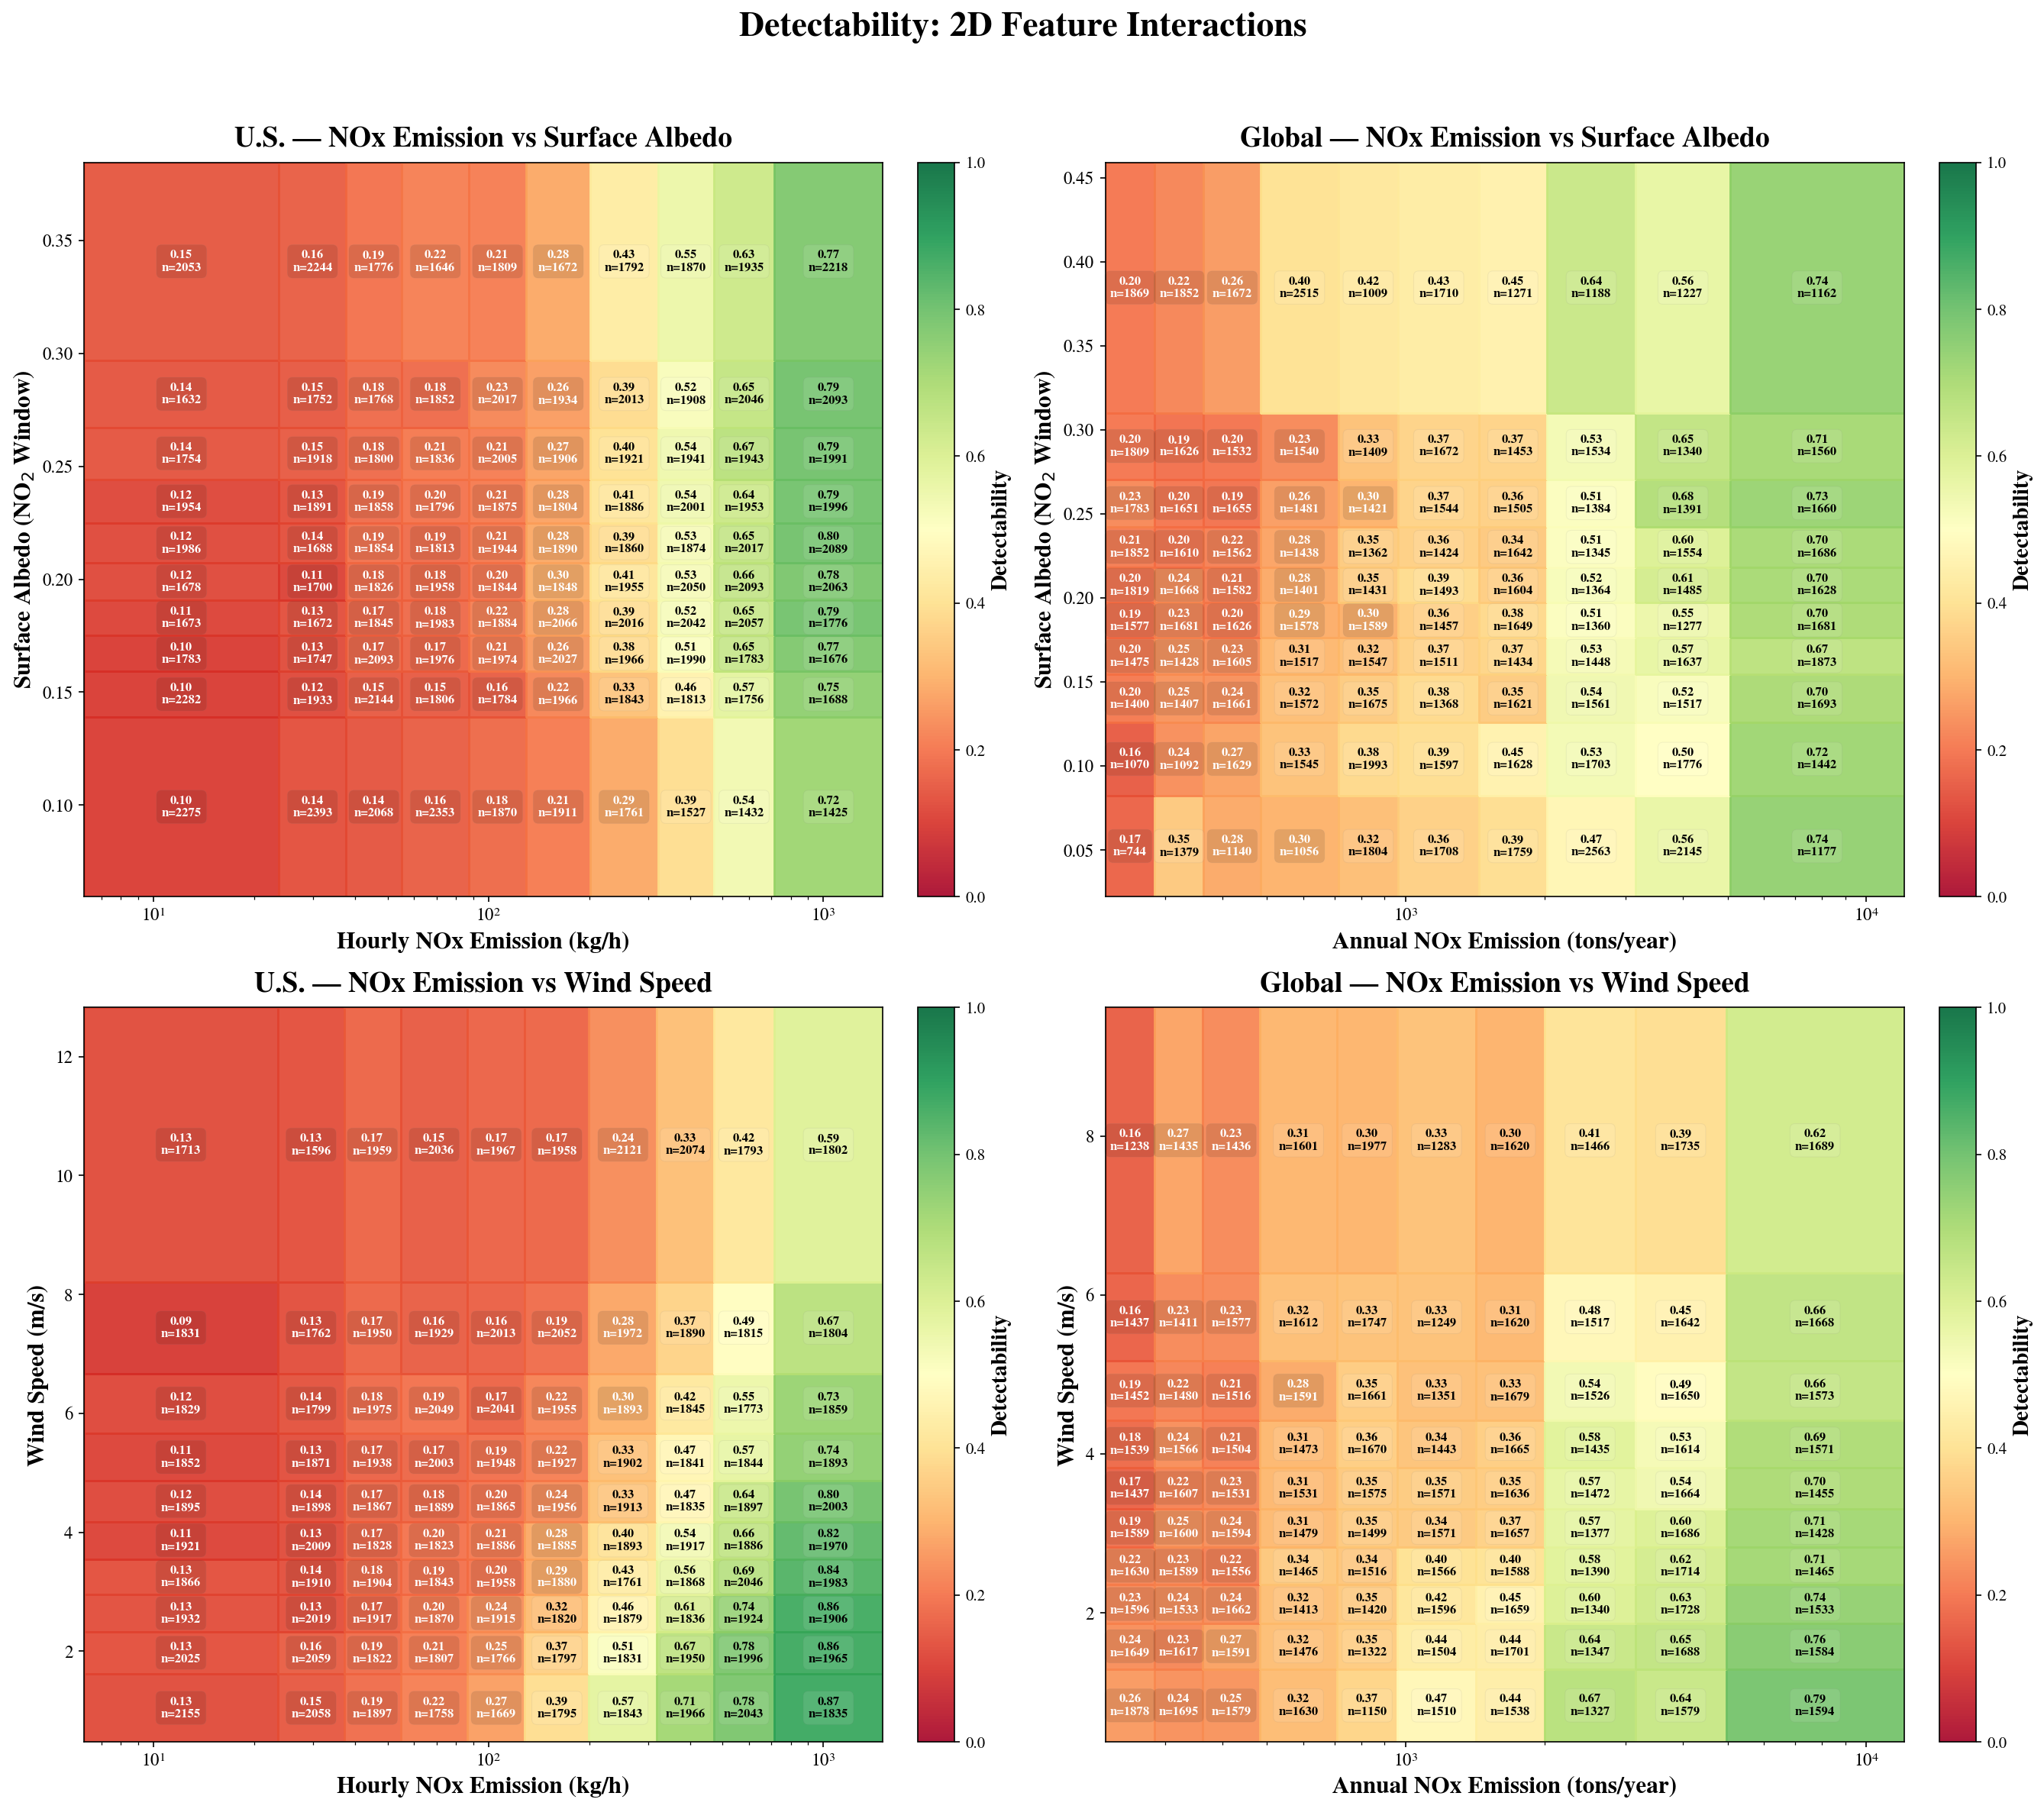

In [7]:
# ── Figure 1: 2x2 grid (US/Global × Albedo/Wind), emission on x-axis ─
fig, axes = plt.subplots(2, 2, figsize=(18, 16), facecolor='white')
fig.suptitle('Detectability: 2D Feature Interactions',
             fontsize=22, fontweight='bold', y=0.995)

print('[1/4] US — emission × albedo')
pod, cnt, xe, ye = compute_2d_pod_heatmap(df_us, us_emis_col, us_alb_col, tgt_us, log_x=True)
plot_2d_heatmap(axes[0, 0], pod, cnt, xe, ye,
                title='U.S. — NOx Emission vs Surface Albedo',
                xlabel=us_label,
                ylabel='Surface Albedo (NO$_2$ Window)', log_x=True)

print('[2/4] Global — emission × albedo')
pod, cnt, xe, ye = compute_2d_pod_heatmap(df_gl, gl_emis_col, gl_alb_col, tgt_gl, log_x=True)
plot_2d_heatmap(axes[0, 1], pod, cnt, xe, ye,
                title='Global — NOx Emission vs Surface Albedo',
                xlabel=gl_label,
                ylabel='Surface Albedo (NO$_2$ Window)', log_x=True)

print('[3/4] US — emission × wind speed')
pod, cnt, xe, ye = compute_2d_pod_heatmap(df_us, us_emis_col, us_wind_col, tgt_us, log_x=True)
plot_2d_heatmap(axes[1, 0], pod, cnt, xe, ye,
                title='U.S. — NOx Emission vs Wind Speed',
                xlabel=us_label,
                ylabel='Wind Speed (m/s)', log_x=True)

print('[4/4] Global — emission × wind speed')
pod, cnt, xe, ye = compute_2d_pod_heatmap(df_gl, gl_emis_col, gl_wind_col, tgt_gl, log_x=True)
plot_2d_heatmap(axes[1, 1], pod, cnt, xe, ye,
                title='Global — NOx Emission vs Wind Speed',
                xlabel=gl_label,
                ylabel='Wind Speed (m/s)', log_x=True)

plt.tight_layout(rect=[0, 0.01, 1, 0.97])
fig.savefig(OUT_DIR / 'pod_2d_heatmap_emission.pdf', dpi=300, bbox_inches='tight')
fig.savefig(OUT_DIR / 'pod_2d_heatmap_emission.png', dpi=300, bbox_inches='tight')
print(f'\n✓ Wrote {OUT_DIR / "pod_2d_heatmap_emission.pdf"}')
print(f'✓ Wrote {OUT_DIR / "pod_2d_heatmap_emission.png"}')
plt.show()

[1/2] US — wind × albedo
[2/2] Global — wind × albedo

✓ Wrote /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/pod_2d_heatmap_wind_albedo.pdf
✓ Wrote /net/fs06/d3/rzhuang/TROPOMI/results/paper_figures/pod_2d_heatmap_wind_albedo.png


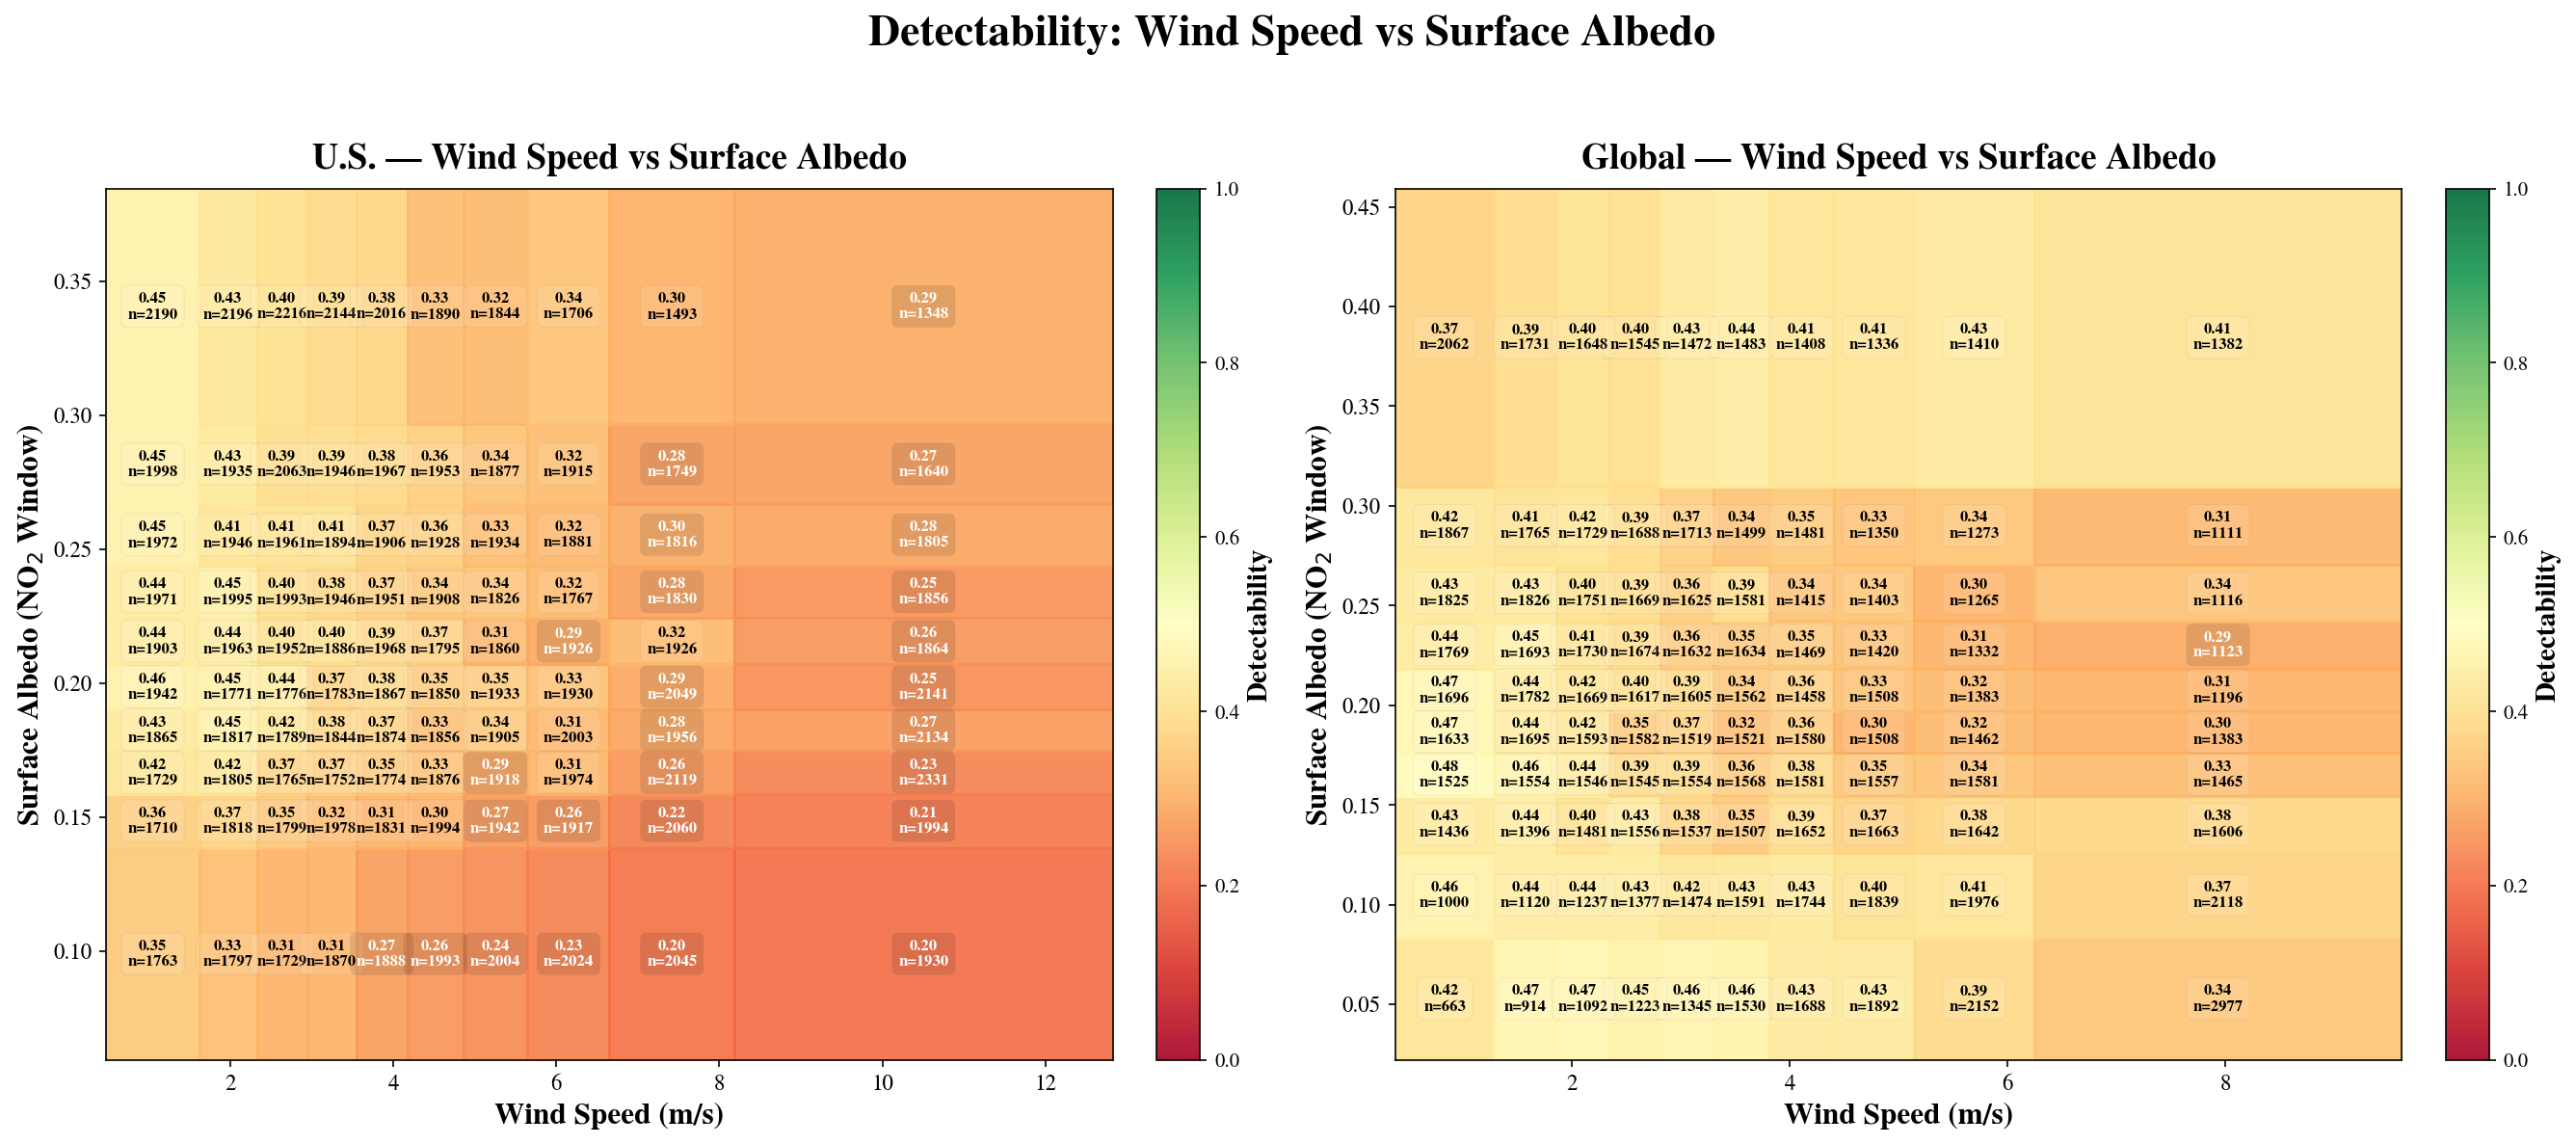

In [8]:
# ── Figure 2: 1x2 grid — Wind Speed (x) vs Surface Albedo (y) ────────
# Both axes linear (no log) since wind & albedo are not heavy-tailed.
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 8), facecolor='white')
fig2.suptitle('Detectability: Wind Speed vs Surface Albedo',
              fontsize=22, fontweight='bold', y=0.995)

print('[1/2] US — wind × albedo')
pod, cnt, xe, ye = compute_2d_pod_heatmap(df_us, us_wind_col, us_alb_col, tgt_us,
                                           log_x=False, log_y=False)
plot_2d_heatmap(axes2[0], pod, cnt, xe, ye,
                title='U.S. — Wind Speed vs Surface Albedo',
                xlabel='Wind Speed (m/s)',
                ylabel='Surface Albedo (NO$_2$ Window)',
                log_x=False, log_y=False)

print('[2/2] Global — wind × albedo')
pod, cnt, xe, ye = compute_2d_pod_heatmap(df_gl, gl_wind_col, gl_alb_col, tgt_gl,
                                           log_x=False, log_y=False)
plot_2d_heatmap(axes2[1], pod, cnt, xe, ye,
                title='Global — Wind Speed vs Surface Albedo',
                xlabel='Wind Speed (m/s)',
                ylabel='Surface Albedo (NO$_2$ Window)',
                log_x=False, log_y=False)

plt.tight_layout(rect=[0, 0.01, 1, 0.96])
fig2.savefig(OUT_DIR / 'pod_2d_heatmap_wind_albedo.pdf', dpi=300, bbox_inches='tight')
fig2.savefig(OUT_DIR / 'pod_2d_heatmap_wind_albedo.png', dpi=300, bbox_inches='tight')
print(f'\n✓ Wrote {OUT_DIR / "pod_2d_heatmap_wind_albedo.pdf"}')
print(f'✓ Wrote {OUT_DIR / "pod_2d_heatmap_wind_albedo.png"}')
plt.show()